# Energy benchmarks: 4 backends — CLX, SPR, V100, H200

Data source: `/Users/u7826985/Projects/Nvidia/results/2026_05_17_eenrgy_benchmarks`

Four backends, two data types (AA `LG+I+G4`, DNA `GTR+I+G4`), three alignment lengths (10k, 100k, 1M sites), 100 taxa.

**Hardware / queue setup**
- **CLX CPU** (Clang-vanilla): NCI `normal` queue, **48 cores reserved**, `-nt 48`. Cascade Lake Xeon Platinum 8274 (~205 W socket TDP).
- **SPR CPU** (Intel-vanilla): NCI `normalsr` queue, **104 cores reserved**, `-nt 103`. Sapphire Rapids 8480+ (~350 W socket TDP).
- **V100** (OpenACC): NCI `gpuvolta` queue, single V100 (250–300 W TDP), `-nt 1` on host.
- **H200** (OpenACC): single H200 (700 W TDP), `-nt 1` on host.

**Coverage notes** — V100 has **no 1M results yet**. CLX has **DNA 1M** but no AA 1M yet. SPR and H200 cover all three lengths.

**Caveat on the GPU "CPU share"** — IQ-TREE is not a pure-GPU code; tree rearrangements, NNI evaluation, BFGS branch-length / model-parameter optimization, model setup, and I/O still run on the host. So the host CPU energy on a GPU run is **real compute work**.

**Metrics**: total runtime (s), total energy (Wh), CPU/Accelerator energy split, log-likelihood agreement.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = '/Users/u7826985/Projects/Nvidia/results/2026_05_17_eenrgy_benchmarks'
OUT_DIR   = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_17_eenrgy_benchmarks'

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 11})
COLORS = {
    'Clang (CLX CPU, OMP=48)':  '#5DA5DA',  # lighter blue (older CPU, Clang-compiled)
    'Intel (SPR CPU, OMP=103)': '#0071C5',  # Intel blue
    'OpenACC (V100)':           '#F2A900',  # amber
    'OpenACC (H200)':           '#76B900',  # NVIDIA green
}
BACKENDS = list(COLORS.keys())  # display order: CLX-CPU, SPR-CPU, V100, H200

## 1. Parse perf reports

Extract total time and the `A breakdown of how the N Wh was used:` block (total energy + CPU% + Accelerator%). Energy can be reported in `Wh` or `kWh` — both handled.

In [2]:
TIME_RE   = re.compile(r'Total time:\s+(\d+)\s+seconds')
ENERGY_RE = re.compile(r'A breakdown of how the\s+([\d.]+)\s+(Wh|kWh) was used:')
CPU_RE    = re.compile(r'^CPU:\s+([\d.]+)%', re.M)
ACC_RE    = re.compile(r'^Accelerators:\s+([\d.]+)%', re.M)
GPU_UTIL_RE = re.compile(r'GPU utilization:\s+([\d.]+)%')

def parse_perf(path):
    txt = open(path).read()
    t = TIME_RE.search(txt)
    e = ENERGY_RE.search(txt)
    if not (t and e):
        return None
    energy_wh = float(e.group(1)) * (1000.0 if e.group(2) == 'kWh' else 1.0)
    cpu_pcts = CPU_RE.findall(txt)
    acc_pcts = ACC_RE.findall(txt)
    gpu_util = GPU_UTIL_RE.search(txt)
    return dict(
        time_s        = int(t.group(1)),
        energy_wh     = energy_wh,
        cpu_pct       = float(cpu_pcts[-1]) if cpu_pcts else np.nan,
        acc_pct       = float(acc_pcts[-1]) if acc_pcts else 0.0,
        gpu_util_pct  = float(gpu_util.group(1)) if gpu_util else np.nan,
    )

def backend_from_name(fname):
    # CLX has two compiler variants in the directory; we only want the Clang-compiled ones.
    if 'h200' in fname.lower():           return 'OpenACC (H200)'
    if 'v100' in fname.lower():           return 'OpenACC (V100)'
    if (fname.startswith('perf_report_CLX_') or fname.startswith('output_CLX_')) \
            and 'CLANG_VANILA' in fname:
        return 'Clang (CLX CPU, OMP=48)'
    if 'intel_compiler' in fname.lower(): return 'Intel (SPR CPU, OMP=103)'
    return 'unknown'

rows = []
for path in sorted(glob.glob(os.path.join(DATA_ROOT, '*', 'len_*', 'perf_report_*.txt'))):
    parts    = path.split(os.sep)
    datatype = parts[-3]
    length   = int(parts[-2].split('_')[1])
    backend  = backend_from_name(os.path.basename(path))
    if backend == 'unknown': continue
    m = parse_perf(path)
    if m is None: continue
    rows.append(dict(datatype=datatype, length=length, backend=backend,
                     file=os.path.basename(path), **m))

perf_raw = pd.DataFrame(rows)
perf_raw

,datatype,length,backend,file,time_s,energy_wh,cpu_pct,acc_pct,gpu_util_pct
0,AA,10000,"Clang (CLX CPU, OMP=48)",perf_report_CLX_test_energy_fix_AA_LG+I+G4_OMP...,430,46.4,100.0,0.0,NaN
1,AA,10000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,400,54.0,63.6,36.4,48.7
2,AA,10000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,252,43.7,100.0,0.0,NaN
3,AA,10000,OpenACC (V100),perf_report_v100_test_energy_AA_LG+I+G4_OPENAC...,607,51.4,59.5,40.5,53.5
4,AA,100000,"Clang (CLX CPU, OMP=48)",perf_report_CLX_test_energy_fix_AA_LG+I+G4_OMP...,3408,393.0,100.0,0.0,NaN
5,AA,100000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,1372,278.0,58.8,41.2,70.4
6,AA,100000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,1115,205.0,100.0,0.0,NaN
7,AA,100000,OpenACC (V100),perf_report_v100_test_energy_AA_LG+I+G4_OPENAC...,2733,261.0,51.2,48.8,72.8
8,AA,1000000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,12269,2100.0,44.9,55.1,65.2
9,AA,1000000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,19792,3530.0,100.0,0.0,NaN


In [3]:
# Some (datatype, length, backend) combinations have multiple perf reports (re-runs).
# Pick the LONGEST runtime per cell (proxy for the complete run; short ones look like aborted attempts).
perf = (perf_raw
        .sort_values('time_s', ascending=False)
        .drop_duplicates(['datatype', 'length', 'backend'], keep='first')
        .sort_values(['datatype', 'length', 'backend'])
        .reset_index(drop=True))
perf['cpu_energy_wh'] = perf['energy_wh'] * perf['cpu_pct'] / 100.0
perf['acc_energy_wh'] = perf['energy_wh'] * perf['acc_pct'] / 100.0
perf

,datatype,length,backend,file,time_s,energy_wh,cpu_pct,acc_pct,gpu_util_pct,cpu_energy_wh,acc_energy_wh
0,AA,10000,"Clang (CLX CPU, OMP=48)",perf_report_CLX_test_energy_fix_AA_LG+I+G4_OMP...,430,46.4,100.0,0.0,NaN,46.4000,0.0000
1,AA,10000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,252,43.7,100.0,0.0,NaN,43.7000,0.0000
2,AA,10000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,400,54.0,63.6,36.4,48.7,34.3440,19.6560
3,AA,10000,OpenACC (V100),perf_report_v100_test_energy_AA_LG+I+G4_OPENAC...,607,51.4,59.5,40.5,53.5,30.5830,20.8170
4,AA,100000,"Clang (CLX CPU, OMP=48)",perf_report_CLX_test_energy_fix_AA_LG+I+G4_OMP...,3408,393.0,100.0,0.0,NaN,393.0000,0.0000
5,AA,100000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,1115,205.0,100.0,0.0,NaN,205.0000,0.0000
6,AA,100000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,1372,278.0,58.8,41.2,70.4,163.4640,114.5360
7,AA,100000,OpenACC (V100),perf_report_v100_test_energy_AA_LG+I+G4_OPENAC...,2733,261.0,51.2,48.8,72.8,133.6320,127.3680
8,AA,1000000,"Intel (SPR CPU, OMP=103)",perf_report_intel_compiler_test_energy_AA_LG+I...,19792,3530.0,100.0,0.0,NaN,3530.0000,0.0000
9,AA,1000000,OpenACC (H200),perf_report_h200_test_energy_AA_LG+I+G4_OPENAC...,12269,2100.0,44.9,55.1,65.2,942.9000,1157.1000


## 2. Parse log-likelihoods
Extract `Log-likelihood of the tree:` from each `.iqtree` file.

In [4]:
LL_RE = re.compile(r'Log-likelihood of the tree:\s+(-?[\d.]+)\s+\(s\.e\.\s+([\d.]+)\)')
rows = []
for path in sorted(glob.glob(os.path.join(DATA_ROOT, '*', 'len_*', 'output_*.iqtree'))):
    parts    = path.split(os.sep)
    datatype = parts[-3]
    length   = int(parts[-2].split('_')[1])
    backend  = backend_from_name(os.path.basename(path))
    m = LL_RE.search(open(path).read())
    if not m: continue
    rows.append(dict(datatype=datatype, length=length, backend=backend,
                     logL=float(m.group(1)), se=float(m.group(2))))

ll = pd.DataFrame(rows).sort_values(['datatype', 'length', 'backend']).reset_index(drop=True)
ll

,datatype,length,backend,logL,se
0,AA,10000,"Clang (CLX CPU, OMP=48)",-8.073500e+05,5092.9035
1,AA,10000,"Intel (SPR CPU, OMP=103)",-8.073500e+05,5092.9035
2,AA,10000,OpenACC (H200),-8.073500e+05,5092.9035
3,AA,10000,OpenACC (V100),-8.073500e+05,5092.9035
4,AA,10000,unknown,-8.073500e+05,5092.9035
5,AA,100000,"Clang (CLX CPU, OMP=48)",-7.541977e+06,15407.1523
6,AA,100000,"Intel (SPR CPU, OMP=103)",-7.541977e+06,15407.1523
7,AA,100000,OpenACC (H200),-7.541977e+06,15407.1523
8,AA,100000,OpenACC (V100),-7.541977e+06,15407.1523
9,AA,100000,unknown,-7.541977e+06,15407.1523


In [5]:
# Combine into one summary table and save
summary = perf.merge(ll, on=['datatype', 'length', 'backend'], how='left')
cols    = ['datatype', 'length', 'backend', 'time_s', 'energy_wh',
           'cpu_pct', 'acc_pct', 'cpu_energy_wh', 'acc_energy_wh',
           'gpu_util_pct', 'logL', 'se']
summary = summary[cols]
summary.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)
summary

,datatype,length,backend,time_s,energy_wh,cpu_pct,acc_pct,cpu_energy_wh,acc_energy_wh,gpu_util_pct,logL,se
0,AA,10000,"Clang (CLX CPU, OMP=48)",430,46.4,100.0,0.0,46.4000,0.0000,NaN,-8.073500e+05,5092.9035
1,AA,10000,"Intel (SPR CPU, OMP=103)",252,43.7,100.0,0.0,43.7000,0.0000,NaN,-8.073500e+05,5092.9035
2,AA,10000,OpenACC (H200),400,54.0,63.6,36.4,34.3440,19.6560,48.7,-8.073500e+05,5092.9035
3,AA,10000,OpenACC (V100),607,51.4,59.5,40.5,30.5830,20.8170,53.5,-8.073500e+05,5092.9035
4,AA,100000,"Clang (CLX CPU, OMP=48)",3408,393.0,100.0,0.0,393.0000,0.0000,NaN,-7.541977e+06,15407.1523
5,AA,100000,"Intel (SPR CPU, OMP=103)",1115,205.0,100.0,0.0,205.0000,0.0000,NaN,-7.541977e+06,15407.1523
6,AA,100000,OpenACC (H200),1372,278.0,58.8,41.2,163.4640,114.5360,70.4,-7.541977e+06,15407.1523
7,AA,100000,OpenACC (V100),2733,261.0,51.2,48.8,133.6320,127.3680,72.8,-7.541977e+06,15407.1523
8,AA,1000000,"Intel (SPR CPU, OMP=103)",19792,3530.0,100.0,0.0,3530.0000,0.0000,NaN,-7.860520e+07,49950.5738
9,AA,1000000,OpenACC (H200),12269,2100.0,44.9,55.1,942.9000,1157.1000,65.2,-7.860520e+07,49950.5738


## 3. Speedup and energy-savings table

In [6]:
pv = summary.pivot_table(index=['datatype', 'length'], columns='backend',
                         values=['time_s', 'energy_wh', 'logL'])
SPR  = 'Intel (SPR CPU, OMP=103)'
CLX  = 'Clang (CLX CPU, OMP=48)'
H200 = 'OpenACC (H200)'
V100 = 'OpenACC (V100)'
def col(metric, b):
    return pv[(metric, b)] if (metric, b) in pv.columns else pd.Series(index=pv.index, dtype=float)
ratios = pd.DataFrame({
    'time_s_CLX':       col('time_s', CLX),
    'time_s_SPR':       col('time_s', SPR),
    'time_s_V100':      col('time_s', V100),
    'time_s_H200':      col('time_s', H200),
    'speedup_H200vsSPR':  col('time_s', SPR) / col('time_s', H200),
    'speedup_V100vsSPR':  col('time_s', SPR) / col('time_s', V100),
    'speedup_H200vsCLX':  col('time_s', CLX) / col('time_s', H200),
    'speedup_V100vsCLX':  col('time_s', CLX) / col('time_s', V100),
    'speedup_SPRvsCLX':   col('time_s', CLX) / col('time_s', SPR),
    'speedup_H200vsV100': col('time_s', V100) / col('time_s', H200),
    'energy_Wh_CLX':    col('energy_wh', CLX),
    'energy_Wh_SPR':    col('energy_wh', SPR),
    'energy_Wh_V100':   col('energy_wh', V100),
    'energy_Wh_H200':   col('energy_wh', H200),
    'energy_ratio_SPRoverH200':  col('energy_wh', SPR) / col('energy_wh', H200),
    'energy_ratio_SPRoverV100':  col('energy_wh', SPR) / col('energy_wh', V100),
    'energy_ratio_CLXoverH200':  col('energy_wh', CLX) / col('energy_wh', H200),
    'energy_ratio_CLXoverV100':  col('energy_wh', CLX) / col('energy_wh', V100),
    'energy_ratio_CLXoverSPR':   col('energy_wh', CLX) / col('energy_wh', SPR),
    'logL_CLX':         col('logL', CLX),
    'logL_SPR':         col('logL', SPR),
    'logL_V100':        col('logL', V100),
    'logL_H200':        col('logL', H200),
})
ratios['logL_absdiff_SPRvsH200'] = (col('logL', SPR) - col('logL', H200)).abs()
ratios['logL_absdiff_SPRvsV100'] = (col('logL', SPR) - col('logL', V100)).abs()
ratios['logL_absdiff_CLXvsH200'] = (col('logL', CLX) - col('logL', H200)).abs()
ratios['logL_absdiff_CLXvsV100'] = (col('logL', CLX) - col('logL', V100)).abs()
ratios.to_csv(os.path.join(OUT_DIR, 'ratios.csv'))
ratios.round(3)

time_s_CLX  time_s_SPR  time_s_V100  time_s_H200  \
datatype length                                                      
AA       10000         430.0       252.0        607.0        400.0   
         100000       3408.0      1115.0       2733.0       1372.0   
         1000000         NaN     19792.0          NaN      12269.0   
DNA      10000         229.0       131.0        417.0        289.0   
         100000        656.0       300.0       1038.0        561.0   
         1000000     14439.0      4361.0          NaN       2817.0   

                  speedup_H200vsSPR  speedup_V100vsSPR  speedup_H200vsCLX  \
datatype length                                                             
AA       10000                0.630              0.415              1.075   
         100000               0.813              0.408              2.484   
         1000000              1.613                NaN                NaN   
DNA      10000                0.453              0.314              0.792   
         100000               0.535              0.289              1.169   
         1000000              1.548                NaN              5.126   

                  speedup_V100vsCLX  speedup_SPRvsCLX  speedup_H200vsV100  \
datatype length                                                             
AA       10000                0.708             1.706               1.518   
         100000               1.247             3.057               1.992   
         1000000                NaN               NaN                 NaN   
DNA      10000                0.549             1.748               1.443   
         100000               0.632             2.187               1.850   
         1000000                NaN             3.311                 NaN   

                  ...  energy_ratio_CLXoverV100  energy_ratio_CLXoverSPR  \
datatype length   ...                                                      
AA       10000    ...                     0.903                    1.062   
         100000   ...                     1.506                    1.917   
         1000000  ...                       NaN                      NaN   
DNA      10000    ...                     0.679                    0.983   
         100000   ...                     0.898                    1.349   
         1000000  ...                       NaN                    1.940   

                      logL_CLX      logL_SPR    logL_V100     logL_H200  \
datatype length                                                           
AA       10000   -8.073500e+05 -8.073500e+05  -807350.031 -8.073500e+05   
         100000  -7.541977e+06 -7.541977e+06 -7541976.860 -7.541977e+06   
         1000000           NaN -7.860520e+07          NaN -7.860520e+07   
DNA      10000   -5.642088e+05 -5.642088e+05  -564208.776 -5.642088e+05   
         100000  -5.692985e+06 -5.692985e+06 -5692984.529 -5.692985e+06   
         1000000 -5.920802e+07 -5.920802e+07          NaN -5.920802e+07   

                  logL_absdiff_SPRvsH200  logL_absdiff_SPRvsV100  \
datatype length                                                    
AA       10000                     0.000                    0.00   
         100000                    0.000                    0.00   
         1000000                   0.000                     NaN   
DNA      10000                     0.001                    0.00   
         100000                    0.012                    0.01   
         1000000                   0.033                     NaN   

                  logL_absdiff_CLXvsH200  logL_absdiff_CLXvsV100  
datatype length                                                   
AA       10000                     0.000                    0.00  
         100000                    0.000                    0.00  
         1000000                     NaN                     NaN  
DNA      10000                     0.001                    0.00  
         100000                    0.012                    0.01  

## 4. Runtime comparison (grouped bars, log y)

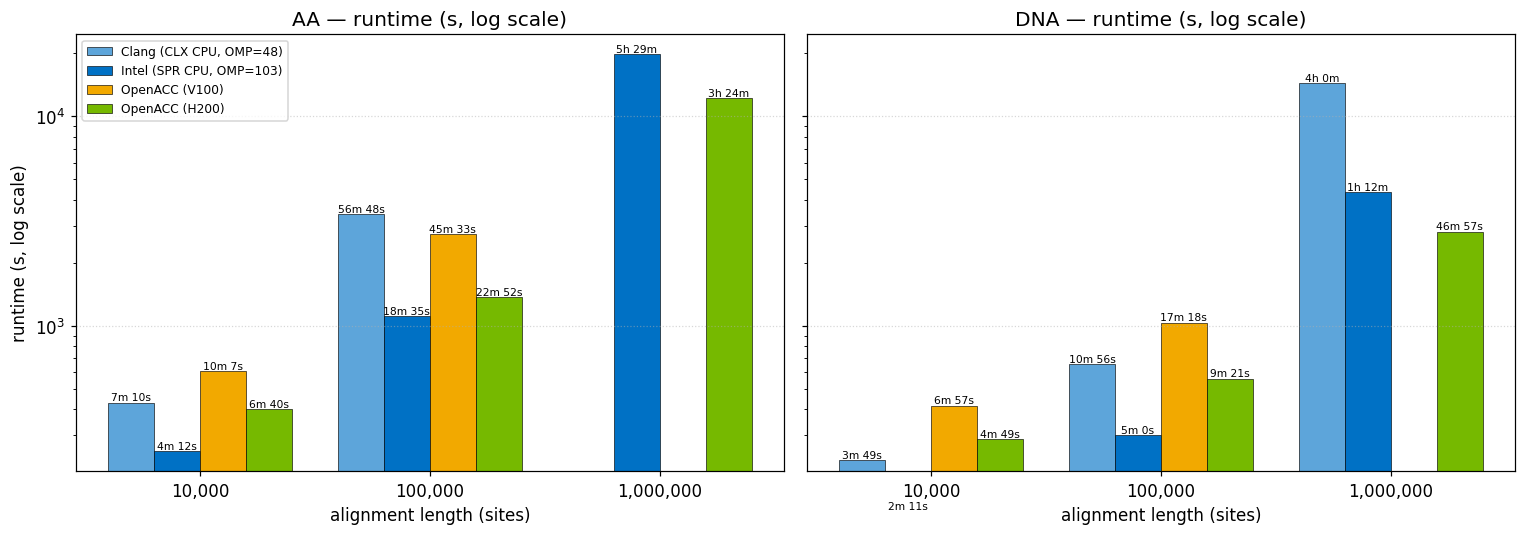

In [7]:
def fmt_hms(seconds):
    s = int(round(seconds))
    h, rem = divmod(s, 3600)
    m, s   = divmod(rem, 60)
    if h:   return f'{h}h {m}m'
    if m:   return f'{m}m {s}s'
    return f'{s}s'

def grouped_bar(metric, ylabel, fname, log_y=True, label_fmt=None, backends=None):
    if label_fmt is None:
        label_fmt = (lambda v: f'{v:,.0f}')
    if backends is None:
        backends = BACKENDS
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    n = len(backends)
    width = 0.8 / n
    offsets = [(i - (n - 1) / 2) * width for i in range(n)]
    for ax, dt in zip(axes, ['AA', 'DNA']):
        sub = summary[summary['datatype'] == dt]
        lengths  = sorted(sub['length'].unique())
        x        = np.arange(len(lengths))
        for i, backend in enumerate(backends):
            vals = []
            positions = []
            for j, L in enumerate(lengths):
                row = sub[(sub['length'] == L) & (sub['backend'] == backend)]
                if row.empty:
                    continue
                vals.append(row[metric].iloc[0])
                positions.append(x[j] + offsets[i])
            if not vals:
                continue
            bars = ax.bar(positions, vals, width, label=backend,
                          color=COLORS[backend], edgecolor='black', linewidth=0.4)
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width()/2, v, label_fmt(v),
                        ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{L:,}' for L in lengths])
        ax.set_xlabel('alignment length (sites)')
        ax.set_title(f'{dt} — {ylabel}')
        if log_y: ax.set_yscale('log')
        ax.grid(axis='y', linestyle=':', alpha=0.5)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), bbox_inches='tight')
    plt.show()

grouped_bar('time_s', 'runtime (s, log scale)', 'runtime_comparison.png', label_fmt=fmt_hms)

## 5. Energy comparison

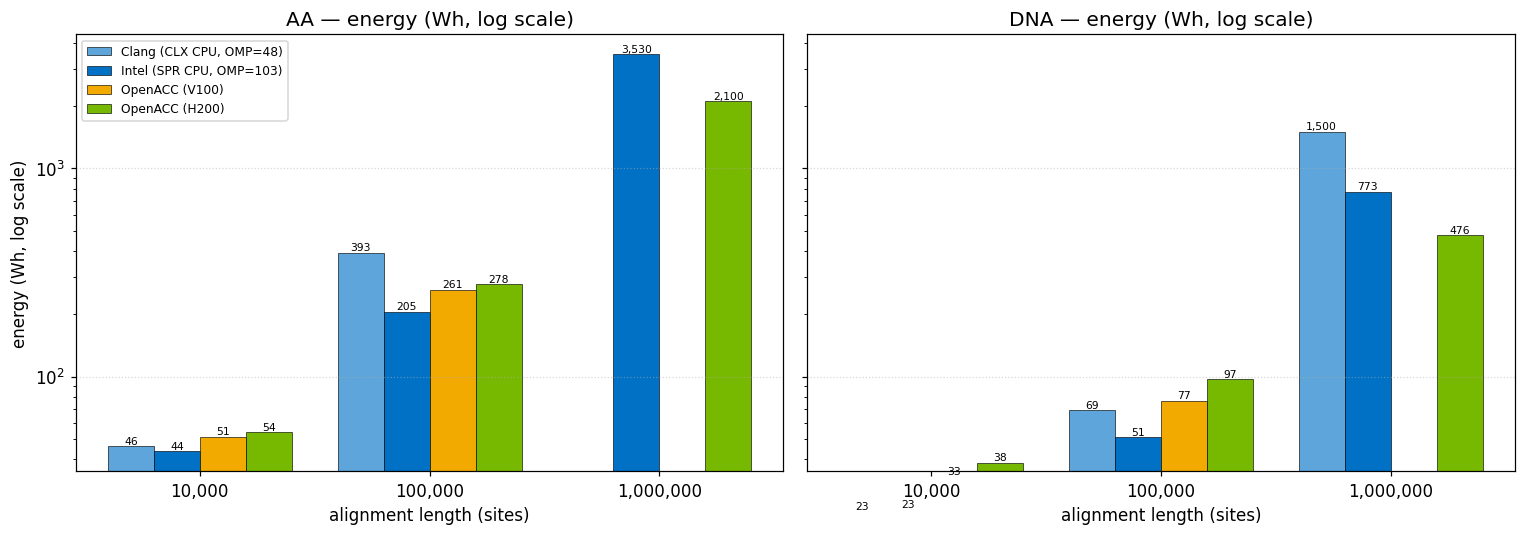

In [8]:
grouped_bar('energy_wh', 'energy (Wh, log scale)',     'energy_comparison.png')

## 6. Stacked energy breakdown (CPU vs Accelerator share)
GPU runs report a CPU/Accelerator split; CPU-only runs are 100% CPU.

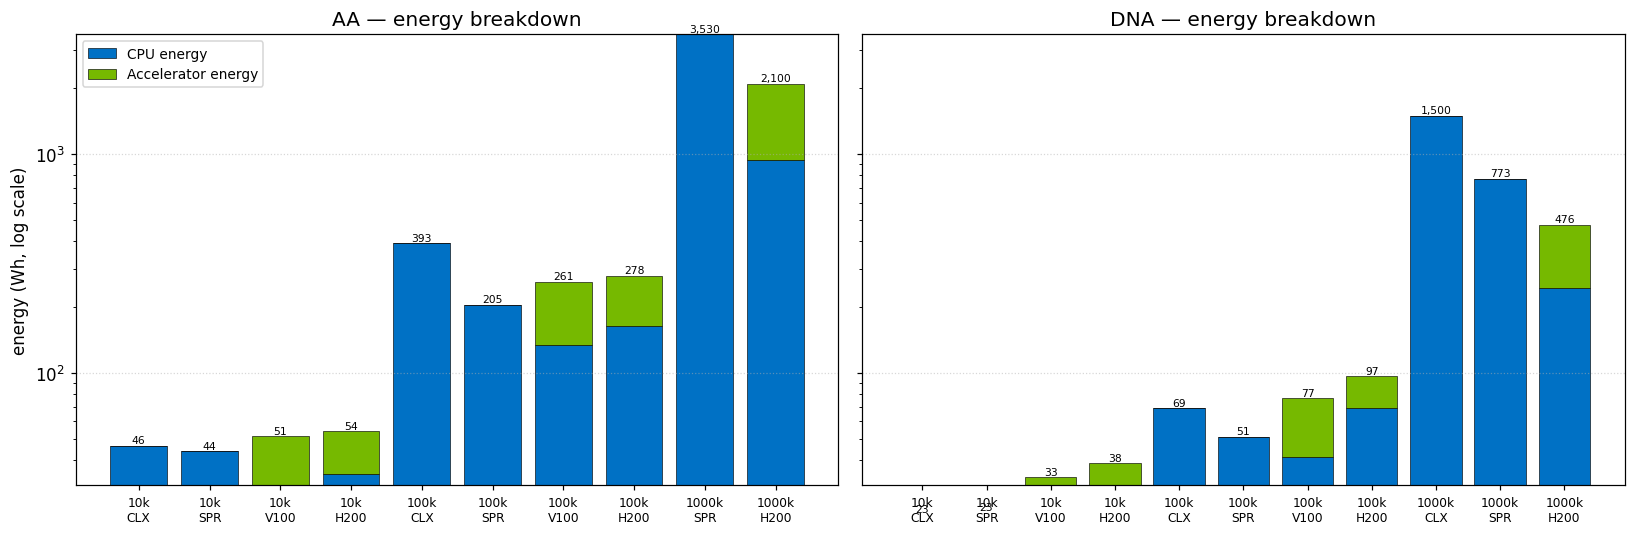

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
BACKEND_SHORT = {'Clang (CLX CPU, OMP=48)': 'CLX',
                 'Intel (SPR CPU, OMP=103)': 'SPR',
                 'OpenACC (V100)': 'V100',
                 'OpenACC (H200)': 'H200'}
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub      = summary[summary['datatype'] == dt]
    lengths  = sorted(sub['length'].unique())
    labels, cpu_e, acc_e = [], [], []
    for L in lengths:
        for backend in BACKENDS:
            row = sub[(sub['length'] == L) & (sub['backend'] == backend)]
            if row.empty:
                continue
            row = row.iloc[0]
            labels.append(f'{L//1000}k\n{BACKEND_SHORT[backend]}')
            cpu_e.append(row['cpu_energy_wh'])
            acc_e.append(row['acc_energy_wh'])
    x = np.arange(len(labels))
    ax.bar(x, cpu_e, color='#0071C5', label='CPU energy',  edgecolor='black', linewidth=0.4)
    ax.bar(x, acc_e, bottom=cpu_e, color='#76B900',        label='Accelerator energy',
           edgecolor='black', linewidth=0.4)
    for xi, (c, a) in enumerate(zip(cpu_e, acc_e)):
        total = c + a
        ax.text(xi, total, f'{total:,.0f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{dt} — energy breakdown')
    ax.set_yscale('log')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
axes[0].set_ylabel('energy (Wh, log scale)')
axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'energy_breakdown.png'), bbox_inches='tight')
plt.show()

## 6b. CPU vs Accelerator share on GPU runs

Highlights that the host CPU consumes the majority of system energy on GPU runs at every size except AA 1M. As problem size grows, the H200 picks up more of the share, but it only crosses 50% on the largest AA case.

**Why so much CPU on a GPU run?** Not all of IQ-TREE has been ported to OpenACC — tree-rearrangement bookkeeping, NNI candidate evaluation, branch-length / model-parameter optimization (BFGS), model setup, and I/O still execute on the host CPU. The blue stack in the chart below is therefore **real work**, not just idle socket power.

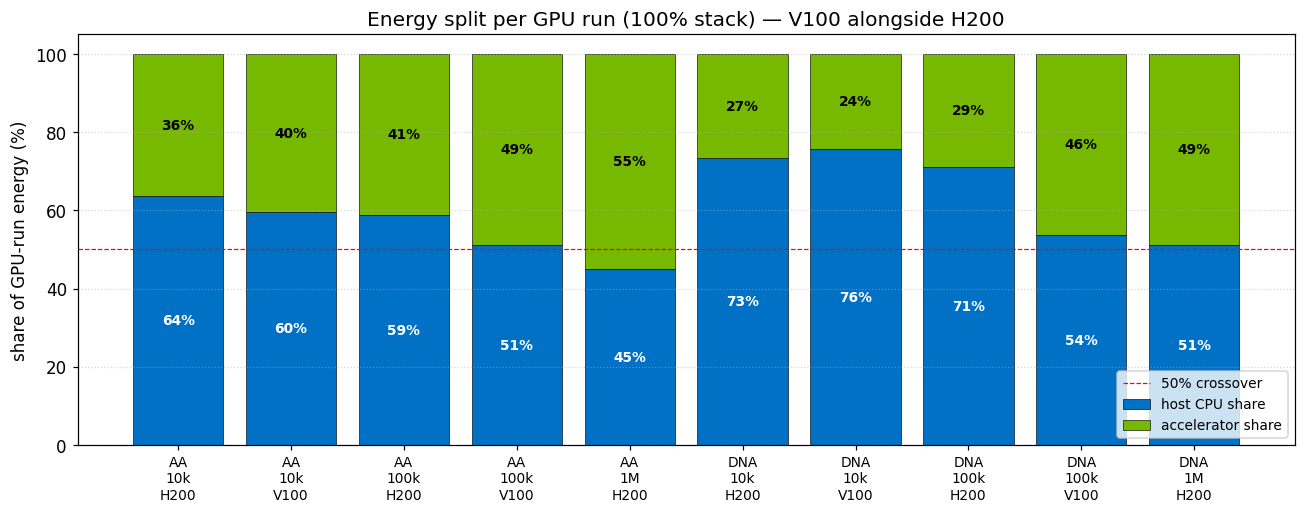

In [10]:
gpu_share = summary[summary['backend'].isin(['OpenACC (H200)', 'OpenACC (V100)'])].copy()
gpu_share = gpu_share.sort_values(['datatype', 'length', 'backend']).reset_index(drop=True)
gpu_short = {'OpenACC (H200)': 'H200', 'OpenACC (V100)': 'V100'}
gpu_share['label'] = (gpu_share['datatype'] + '\n'
                       + gpu_share['length'].apply(lambda L: f'{L//1000}k' if L < 1_000_000 else '1M')
                       + '\n' + gpu_share['backend'].map(gpu_short))

fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(gpu_share))
ax.bar(x, gpu_share['cpu_pct'], color='#0071C5', label='host CPU share', edgecolor='black', linewidth=0.4)
ax.bar(x, gpu_share['acc_pct'], bottom=gpu_share['cpu_pct'], color='#76B900',
       label='accelerator share', edgecolor='black', linewidth=0.4)
ax.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% crossover')
for xi, (cpu, acc) in enumerate(zip(gpu_share['cpu_pct'], gpu_share['acc_pct'])):
    ax.text(xi, cpu/2,         f'{cpu:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(xi, cpu + acc/2,   f'{acc:.0f}%', ha='center', va='center', color='black', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(gpu_share['label'], fontsize=9)
ax.set_ylim(0, 105)
ax.set_ylabel('share of GPU-run energy (%)')
ax.set_title('Energy split per GPU run (100% stack) \u2014 V100 alongside H200')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cpu_acc_share.png'), bbox_inches='tight')
plt.show()

## 7. Speedup and energy-ratio (GPU vs CPU)

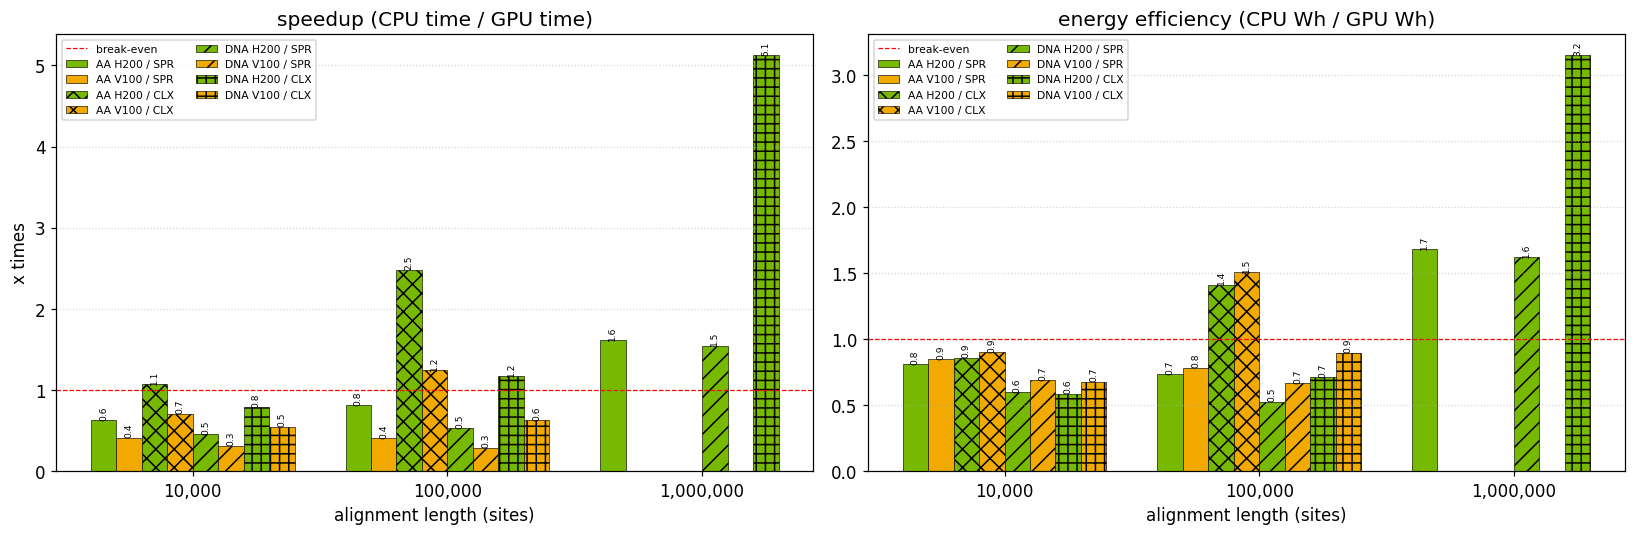

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
lengths = sorted(summary['length'].unique())
x       = np.arange(len(lengths))
width   = 0.10
GROUPS = [  # (dt, gpu_short, cpu_short, speedup_col, energy_col, color, hatch)
    ('AA',  'H200', 'SPR', 'speedup_H200vsSPR',  'energy_ratio_SPRoverH200',  COLORS['OpenACC (H200)'], None),
    ('AA',  'V100', 'SPR', 'speedup_V100vsSPR',  'energy_ratio_SPRoverV100',  COLORS['OpenACC (V100)'], None),
    ('AA',  'H200', 'CLX', 'speedup_H200vsCLX',  'energy_ratio_CLXoverH200',  COLORS['OpenACC (H200)'], 'xx'),
    ('AA',  'V100', 'CLX', 'speedup_V100vsCLX',  'energy_ratio_CLXoverV100',  COLORS['OpenACC (V100)'], 'xx'),
    ('DNA', 'H200', 'SPR', 'speedup_H200vsSPR',  'energy_ratio_SPRoverH200',  COLORS['OpenACC (H200)'], '//'),
    ('DNA', 'V100', 'SPR', 'speedup_V100vsSPR',  'energy_ratio_SPRoverV100',  COLORS['OpenACC (V100)'], '//'),
    ('DNA', 'H200', 'CLX', 'speedup_H200vsCLX',  'energy_ratio_CLXoverH200',  COLORS['OpenACC (H200)'], '++'),
    ('DNA', 'V100', 'CLX', 'speedup_V100vsCLX',  'energy_ratio_CLXoverV100',  COLORS['OpenACC (V100)'], '++'),
]
n = len(GROUPS)
offsets = [(i - (n - 1) / 2) * width for i in range(n)]
for ax, kind, title in [
    (axes[0], 'speedup', 'speedup (CPU time / GPU time)'),
    (axes[1], 'energy',  'energy efficiency (CPU Wh / GPU Wh)'),
]:
    for i, (dt, gname, cname, smet, emet, color, hatch) in enumerate(GROUPS):
        metric = smet if kind == 'speedup' else emet
        vals, positions = [], []
        for j, L in enumerate(lengths):
            v = ratios.loc[(dt, L), metric] if (dt, L) in ratios.index else np.nan
            if pd.notna(v):
                vals.append(v)
                positions.append(x[j] + offsets[i])
        if not vals: continue
        bars = ax.bar(positions, vals, width, color=color, edgecolor='black', linewidth=0.4,
                      hatch=hatch, label=f'{dt} {gname} / {cname}')
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=6, rotation=90)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, label='break-even')
    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_xlabel('alignment length (sites)')
    ax.set_title(title)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, ncol=2)
axes[0].set_ylabel('x times')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'speedup_and_energy_ratio.png'), bbox_inches='tight')
plt.show()

## 8. Log-likelihood agreement
Tree-search numerics should match closely between backends — these plots quantify the absolute and relative disagreement.

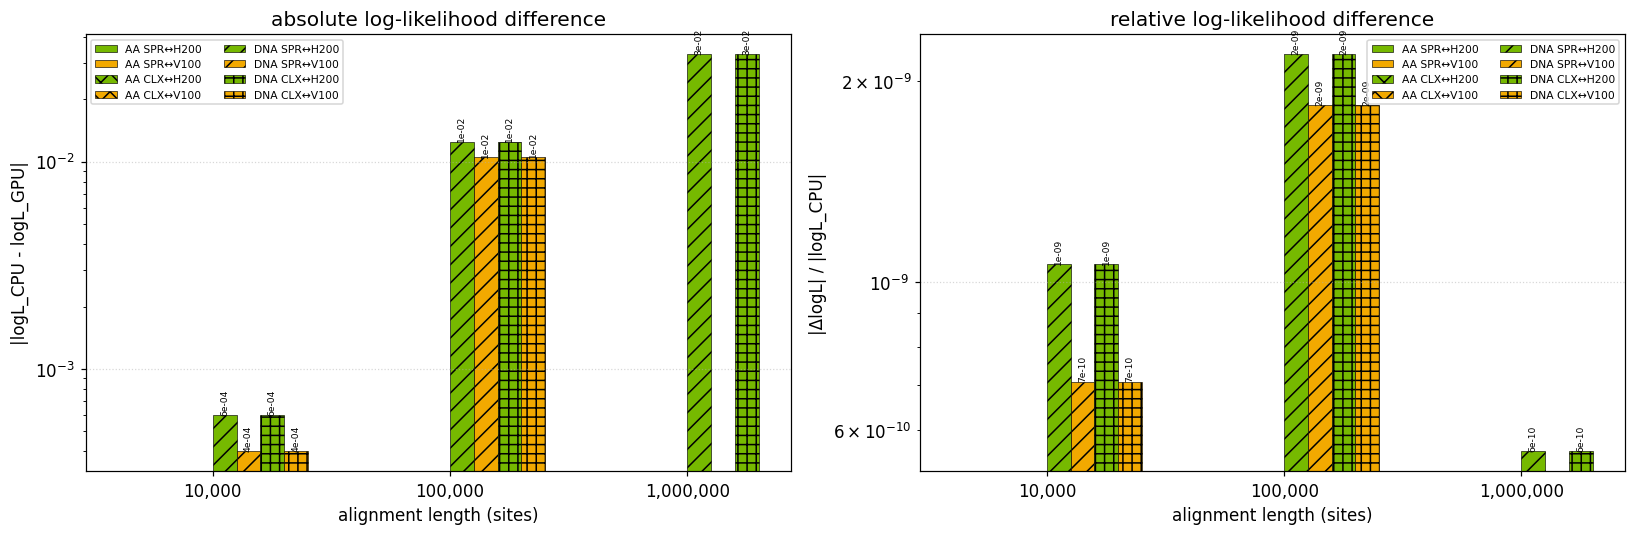

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
lengths = sorted(summary['length'].unique())
x       = np.arange(len(lengths))
width   = 0.10
GROUPS = [
    ('AA',  'H200', 'SPR', 'logL_absdiff_SPRvsH200', COLORS['OpenACC (H200)'], None),
    ('AA',  'V100', 'SPR', 'logL_absdiff_SPRvsV100', COLORS['OpenACC (V100)'], None),
    ('AA',  'H200', 'CLX', 'logL_absdiff_CLXvsH200', COLORS['OpenACC (H200)'], 'xx'),
    ('AA',  'V100', 'CLX', 'logL_absdiff_CLXvsV100', COLORS['OpenACC (V100)'], 'xx'),
    ('DNA', 'H200', 'SPR', 'logL_absdiff_SPRvsH200', COLORS['OpenACC (H200)'], '//'),
    ('DNA', 'V100', 'SPR', 'logL_absdiff_SPRvsV100', COLORS['OpenACC (V100)'], '//'),
    ('DNA', 'H200', 'CLX', 'logL_absdiff_CLXvsH200', COLORS['OpenACC (H200)'], '++'),
    ('DNA', 'V100', 'CLX', 'logL_absdiff_CLXvsV100', COLORS['OpenACC (V100)'], '++'),
]
n = len(GROUPS)
offsets = [(i - (n - 1) / 2) * width for i in range(n)]
for ax, mode, ylabel in [
    (axes[0], 'abs', '|logL_CPU - logL_GPU|'),
    (axes[1], 'rel', '|\u0394logL| / |logL_CPU|'),
]:
    for i, (dt, gname, cname, abs_col, color, hatch) in enumerate(GROUPS):
        ref_col = 'logL_SPR' if cname == 'SPR' else 'logL_CLX'
        vals, positions = [], []
        for j, L in enumerate(lengths):
            if (dt, L) not in ratios.index: continue
            a = ratios.loc[(dt, L), abs_col]
            if pd.isna(a) or pd.isna(ratios.loc[(dt, L), ref_col]):
                continue
            v = a if mode == 'abs' else a / abs(ratios.loc[(dt, L), ref_col])
            vals.append(v)
            positions.append(x[j] + offsets[i])
        if not vals: continue
        bars = ax.bar(positions, vals, width, color=color, edgecolor='black', linewidth=0.4,
                      hatch=hatch, label=f'{dt} {cname}\u2194{gname}')
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width()/2, v, f'{v:.0e}',
                        ha='center', va='bottom', fontsize=6, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_xlabel('alignment length (sites)')
    ax.set_ylabel(ylabel)
    ax.set_yscale('log')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=7, ncol=2)
axes[0].set_title('absolute log-likelihood difference')
axes[1].set_title('relative log-likelihood difference')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'logL_agreement.png'), bbox_inches='tight')
plt.show()

## 8b. Best log-likelihood heatmap
Heatmap of the best score (log-likelihood from `.iqtree`) per backend × alignment length, one panel per datatype. Cells are annotated with the raw value; color is scaled per column so the two backends within the same length are visually comparable (otherwise the 10k vs 1M magnitude difference dominates).

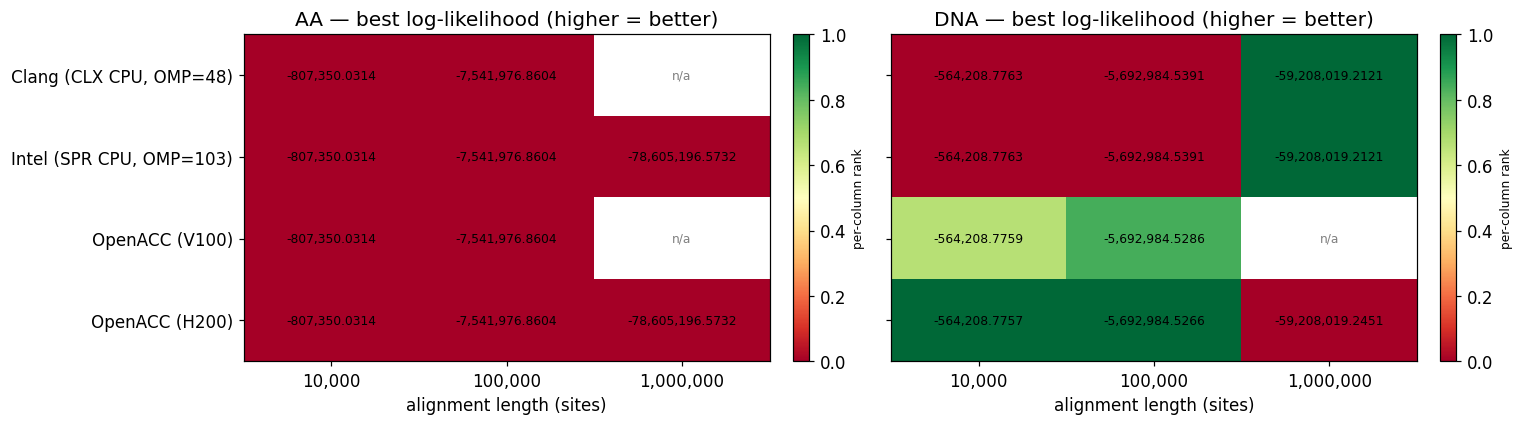

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
lengths  = sorted(summary['length'].unique())

for ax, dt in zip(axes, ['AA', 'DNA']):
    mat = np.full((len(BACKENDS), len(lengths)), np.nan)
    for i, b in enumerate(BACKENDS):
        for j, L in enumerate(lengths):
            row = summary[(summary['datatype'] == dt) &
                          (summary['length'] == L) &
                          (summary['backend'] == b)]
            if not row.empty:
                mat[i, j] = row['logL'].iloc[0]
    col_min = np.nanmin(mat, axis=0, keepdims=True)
    col_max = np.nanmax(mat, axis=0, keepdims=True)
    rng     = np.where(col_max == col_min, 1.0, col_max - col_min)
    norm    = (mat - col_min) / rng
    im = ax.imshow(norm, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(lengths)));  ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_yticks(range(len(BACKENDS))); ax.set_yticklabels(BACKENDS)
    ax.set_xlabel('alignment length (sites)')
    ax.set_title(f'{dt} \u2014 best log-likelihood (higher = better)')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:,.4f}', ha='center', va='center', fontsize=8, color='black')
            else:
                ax.text(j, i, 'n/a', ha='center', va='center', fontsize=8, color='gray')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('per-column rank', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'best_score_heatmap.png'), bbox_inches='tight')
plt.show()

## 9. Energy-per-site and throughput
Normalises by alignment length so the three problem sizes can be compared directly.

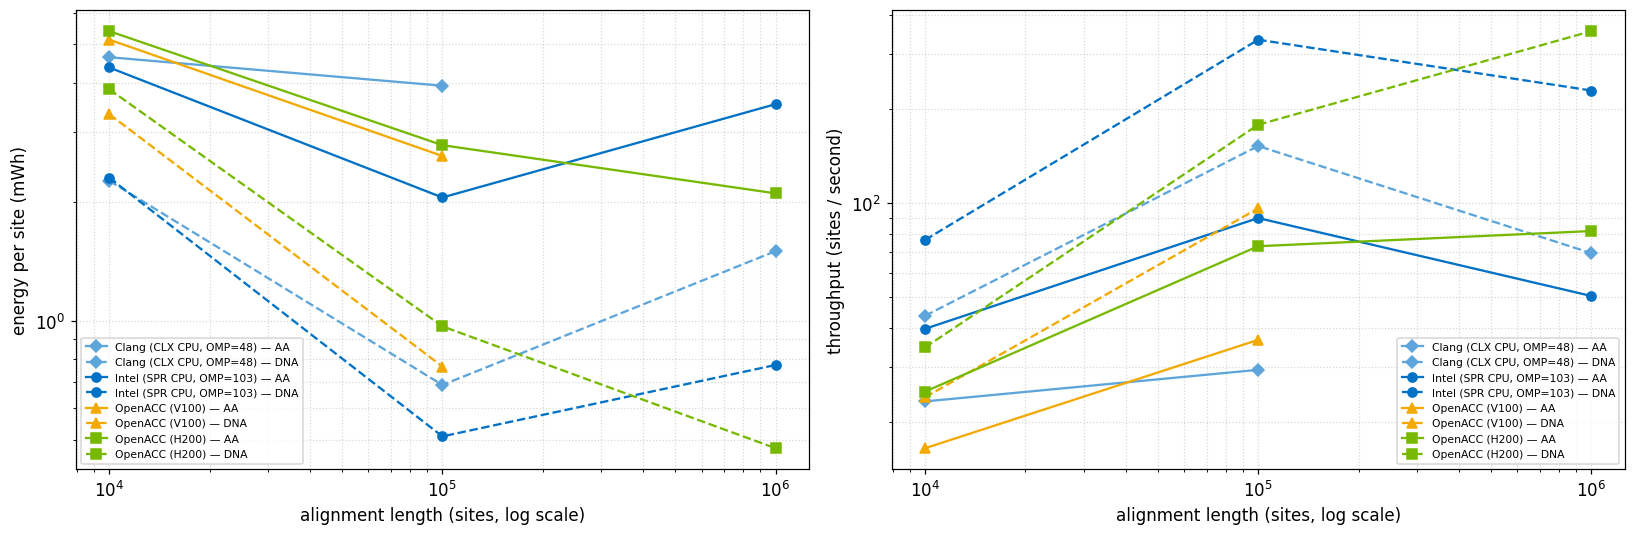

In [14]:
summary['energy_per_site_mWh'] = summary['energy_wh'] * 1000.0 / summary['length']
summary['sites_per_sec']       = summary['length'] / summary['time_s']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
MARKERS = {'Clang (CLX CPU, OMP=48)': 'D',
           'Intel (SPR CPU, OMP=103)': 'o',
           'OpenACC (V100)': '^',
           'OpenACC (H200)': 's'}
for ax, metric, ylabel in [
    (axes[0], 'energy_per_site_mWh', 'energy per site (mWh)'),
    (axes[1], 'sites_per_sec',       'throughput (sites / second)'),
]:
    for backend in BACKENDS:
        for dt, ls in [('AA', '-'), ('DNA', '--')]:
            sub = summary[(summary['backend'] == backend) & (summary['datatype'] == dt)] \
                    .sort_values('length')
            if sub.empty:
                continue
            ax.plot(sub['length'], sub[metric], marker=MARKERS[backend], linestyle=ls,
                    color=COLORS[backend], label=f'{backend} — {dt}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('alignment length (sites, log scale)')
    ax.set_ylabel(ylabel)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'normalised_metrics.png'), bbox_inches='tight')
plt.show()

## 10. Take-aways

The numbers below are filled in from `ratios.csv` after the cells above run.

In [15]:
for col in ['speedup_H200vsSPR', 'speedup_V100vsSPR',
            'speedup_H200vsCLX', 'speedup_V100vsCLX',
            'energy_ratio_SPRoverH200', 'energy_ratio_SPRoverV100',
            'energy_ratio_CLXoverH200', 'energy_ratio_CLXoverV100',
            'energy_ratio_CLXoverSPR']:
    print(col)
    print(ratios[col].round(2).to_string(), '\n')

speedup_H200vsSPR
datatype  length 
AA        10000      0.63
          100000     0.81
          1000000    1.61
DNA       10000      0.45
          100000     0.53
          1000000    1.55 

speedup_V100vsSPR
datatype  length 
AA        10000      0.42
          100000     0.41
          1000000     NaN
DNA       10000      0.31
          100000     0.29
          1000000     NaN 

speedup_H200vsCLX
datatype  length 
AA        10000      1.08
          100000     2.48
          1000000     NaN
DNA       10000      0.79
          100000     1.17
          1000000    5.13 

speedup_V100vsCLX
datatype  length 
AA        10000      0.71
          100000     1.25
          1000000     NaN
DNA       10000      0.55
          100000     0.63
          1000000     NaN 

energy_ratio_SPRoverH200
datatype  length 
AA        10000      0.81
          100000     0.74
          1000000    1.68
DNA       10000      0.60
          100000     0.53
          1000000    1.62 

energy_ratio_SPRoverV10

## 11. Observations

- **V100 is more energy efficient than H200** for every cell measured (≤100k sites). V100 wins by 5–21%: AA 10k 51 vs 54 Wh, AA 100k 261 vs 278 Wh, DNA 10k 33 vs 39 Wh, DNA 100k 77 vs 97 Wh. The V100 node draws ~300 W on average vs the H200 node's ~600 W — roughly the TDP ratio. (V100 1M results pending.)

- **Energy ratio tracks runtime ratio for H200 vs SPR** at 100k+ sites (almost exact at AA 1M and DNA 100k). At 10k the H200 looks better on energy than on runtime because a fully-loaded SPR socket draws more average power than an under-utilized H200.

- **OpenACC energy consumption is dominated by the host CPU, not the accelerator, on every H200 cell except AA 1M.** Host CPU share — AA: 64% / 59% / 45%, DNA: 73% / 71% / 51%. The bulk is real work: IQ-TREE's NNI evaluation, BFGS branch-length / model optimization, model setup, and I/O are not OpenACC-ported and still run on the host.

- **The accelerator only crosses 50% of system energy in the largest AA case** (AA 1M, 55% accelerator share). DNA 1M comes close at 49% but stays under. Every smaller cell is host-dominated.

- **At small DNA sizes, the host CPU portion of an H200 run exceeds a complete SPR CPU-only run** — DNA 10k: 28 Wh host portion vs 23 Wh full SPR run; DNA 100k: 69 Wh vs 51 Wh. The GPU run is long enough that the host's idle / orchestration draw outpaces a fast, finished CPU job.

- **Historical context** — previous tests pitted V100 against Cascade Lake CPUs with the **GCC-compiled** IQ-TREE build, which was much slower than the current Intel-vanilla / SPR runtime. Against that weaker CPU baseline the V100's low absolute power stood out, and the V100 looked dramatically more energy efficient. The current Intel-vanilla CPU has closed most of that gap — V100 still beats H200 on energy here, and still beats CLX on AA 100k, but no longer dominates the way it did against GCC + CLX.